# 01. Preprocesamiento de Bank Marketing


## Objetivo del cuaderno

Este cuaderno prepara el conjunto de datos **Bank Marketing** para el problema de clasificación binaria. La variable objetivo es `y`, que indica si el cliente contrató o no el depósito bancario.

El análisis se limita al escenario sin `duration`, ya que esta variable solo se conoce una vez finalizada la llamada y su uso proporcionaría una ventaja predictiva poco realista.


#### Índice

1. Librerías utilizadas.
2. Carga del conjunto de datos Bank Marketing.
3. Revisión inicial.
4. Tratamiento de los valores `unknown`.
5. Variable objetivo y distribución de clases.
6. Eliminación de la variable `duration`.
7. Preparación del conjunto de datos de clasificación.
8. División en entrenamiento y prueba.
9. Guardado de los datos procesados.


## 1. Librerías utilizadas


In [1]:
import os

import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split


## 2. Carga del conjunto de datos Bank Marketing

El archivo original utiliza `;` como separador. Si no se encuentra en la ruta esperada, la ejecución se detiene con un mensaje explícito.


In [2]:
ruta_bank = "../../data/raw/clasificacion/bank-full.csv"

if not os.path.exists(ruta_bank):
    raise FileNotFoundError(f"No se encuentra el archivo: {ruta_bank}")

bank = pd.read_csv(ruta_bank, sep=";")

resumen_carga = pd.DataFrame([
    {
        "dataset": "Bank Marketing",
        "archivo": "bank-full.csv",
        "filas": bank.shape[0],
        "columnas": bank.shape[1],
    }
])

resumen_carga

,dataset,archivo,filas,columnas
0,Bank Marketing,bank-full.csv,45211,17


## 3. Revisión inicial

En este bloque se examinan la estructura, las dimensiones y los tipos de las variables del conjunto de datos, así como la presencia de valores ausentes y registros duplicados.


In [3]:
print(f"Dimensiones del dataset: {bank.shape[0]} filas y {bank.shape[1]} columnas")
bank.head()


Dimensiones del dataset: 45211 filas y 17 columnas


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
tabla_tipos = pd.DataFrame({
    "variable": bank.columns,
    "tipo": [str(bank[col].dtype) for col in bank.columns],
    "valores_unicos": [bank[col].nunique(dropna=False) for col in bank.columns],
    "nulos": [bank[col].isna().sum() for col in bank.columns],
})

tabla_tipos


,variable,tipo,valores_unicos,nulos
0,age,int64,77,0
1,job,str,12,0
2,marital,str,3,0
3,education,str,4,0
4,default,str,2,0
5,balance,int64,7168,0
6,housing,str,2,0
7,loan,str,2,0
8,contact,str,3,0
9,day,int64,31,0


## 4. Tratamiento de los valores `unknown`

El valor `unknown` aparece en algunas variables categóricas. Se conserva como una categoría válida, en lugar de tratarlo como un valor perdido, porque indica que la característica correspondiente no estaba disponible o no fue registrada.


In [5]:
columnas_categoricas = [
    col for col in bank.columns
    if pd.api.types.is_string_dtype(bank[col])
]

tabla_unknown = pd.DataFrame([
    {
        "variable": col,
        "n_unknown": int((bank[col] == "unknown").sum()),
        "porcentaje_unknown": (bank[col] == "unknown").mean(),
    }
    for col in columnas_categoricas
])

tabla_unknown = tabla_unknown.sort_values("n_unknown", ascending=False)
tabla_unknown[tabla_unknown["n_unknown"] > 0]


,variable,n_unknown,porcentaje_unknown
8,poutcome,36959,0.817478
6,contact,13020,0.287983
2,education,1857,0.041074
0,job,288,0.006370


## 5. Variable objetivo y distribución de clases

La variable objetivo es `y` y presenta dos clases: `yes` cuando el cliente contrata el producto y `no` cuando no lo contrata. Se revisa su distribución para caracterizar el posible desbalanceo del problema de clasificación.


In [6]:
distribucion_objetivo = (
    bank["y"]
    .value_counts()
    .rename_axis("clase")
    .reset_index(name="frecuencia")
)
distribucion_objetivo["porcentaje"] = distribucion_objetivo["frecuencia"] / len(bank)

distribucion_objetivo


,clase,frecuencia,porcentaje
0,no,39922,0.883015
1,yes,5289,0.116985


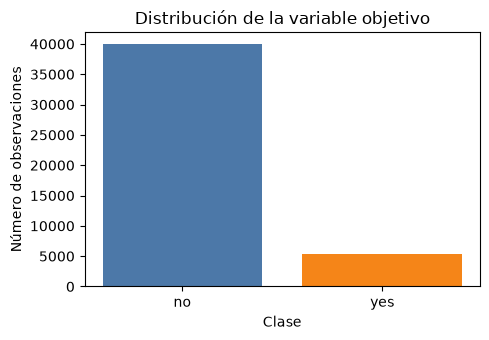

In [7]:
os.makedirs("../../reports/figures/serie_computacional", exist_ok=True)

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(
    distribucion_objetivo["clase"],
    distribucion_objetivo["frecuencia"],
    color=["#4c78a8", "#f58518"]
)
ax.set_title("Distribución de la variable objetivo")
ax.set_xlabel("Clase")
ax.set_ylabel("Número de observaciones")
fig.tight_layout()
fig.savefig(
    "../../reports/figures/serie_computacional/bank_distribucion_objetivo.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()


## 6. Eliminación de la variable `duration`

La variable `duration` mide la duración de la llamada y posee una elevada capacidad predictiva. Sin embargo, solo se conoce una vez finalizado el contacto, por lo que se elimina antes de preparar los datos de modelado para evitar un escenario de evaluación poco realista.


In [8]:
resumen_duration = bank["duration"].describe().to_frame(name="duration")
resumen_duration


,duration
count,45211.000000
mean,258.163080
std,257.527812
min,0.000000
25%,103.000000
50%,180.000000
75%,319.000000
max,4918.000000


## 7. Preparación del conjunto de datos de clasificación

La variable objetivo se transforma a formato binario (`no = 0`, `yes = 1`) y `duration` se excluye del conjunto de variables predictoras.


In [9]:
bank_modelo = bank.drop(columns=["duration"]).copy()
bank_modelo["y"] = bank_modelo["y"].map({"no": 0, "yes": 1})

variables_modelo = [col for col in bank_modelo.columns if col != "y"]

resumen_dataset_modelo = pd.DataFrame([
    {
        "dataset": "bank_sin_duration",
        "numero_variables": len(variables_modelo),
        "incluye_duration": "no",
    }
])

resumen_dataset_modelo


,dataset,numero_variables,incluye_duration
0,bank_sin_duration,15,no


## 8. División en entrenamiento y prueba

La separación se realiza con una semilla fija y mediante estratificación, con el fin de mantener una proporción de clases semejante en los conjuntos de entrenamiento y prueba.


In [10]:
bank_train, bank_test = train_test_split(
    bank_modelo,
    test_size=0.20,
    random_state=42,
    stratify=bank_modelo["y"]
)

resumen_splits = pd.DataFrame([
    {
        "conjunto": "train",
        "filas": bank_train.shape[0],
        "columnas": bank_train.shape[1],
        "porcentaje_y_1": bank_train["y"].mean(),
    },
    {
        "conjunto": "test",
        "filas": bank_test.shape[0],
        "columnas": bank_test.shape[1],
        "porcentaje_y_1": bank_test["y"].mean(),
    },
])

resumen_splits


,conjunto,filas,columnas,porcentaje_y_1
0,train,36168,16,0.116982
1,test,9043,16,0.116997


## 9. Guardado de los datos procesados

En este bloque se guardan los conjuntos procesados que utilizarán los cuadernos de modelado. También se conservan las tablas de apoyo necesarias para documentar la revisión inicial.


In [11]:
os.makedirs("../../data/processed/serie_computacional", exist_ok=True)
os.makedirs("../../reports/tables/serie_computacional", exist_ok=True)
os.makedirs("../../reports/figures/serie_computacional", exist_ok=True)

bank_train.to_csv(
    "../../data/processed/serie_computacional/bank_train_sin_duration.csv",
    index=False,
)

bank_test.to_csv(
    "../../data/processed/serie_computacional/bank_test_sin_duration.csv",
    index=False,
)

tablas_salida = {
    "bank_tipos_variables.csv": tabla_tipos,
    "bank_unknown_por_variable.csv": tabla_unknown,
    "bank_distribucion_objetivo.csv": distribucion_objetivo,
    "bank_resumen_dataset_modelo.csv": resumen_dataset_modelo,
    "bank_resumen_splits.csv": resumen_splits,
}

for nombre_archivo, tabla in tablas_salida.items():
    ruta_salida = f"../../reports/tables/serie_computacional/{nombre_archivo}"
    tabla.to_csv(ruta_salida, index=False)